In [ ]:
# Install the necessary modules for the project
!pip install matplotlib
!pip install openpyxl
!pip install kmodes
!pip install --upgrade kmodes

In [ ]:
# Import the libraries required for the project

# Data manipulation and numerical analysis
import pandas as pd
import numpy as np

# Data visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Text processing and pattern matching
import re

# Graphs and network analysis
import networkx as nx

# Random utilities
import random

# Clustering algorithms
from kmodes.kmodes import KModes
from kmodes.kprototypes import KPrototypes
from kmodes.kmodes import KModes
from sklearn.preprocessing import LabelEncoder

# Counting and frequency analysis
from collections import Counter

In [ ]:
# Reading the incident dataset
df = pd.read_excel('HRA_dataset.xlsx')
df.head(30)

,Time,SeniorLeader,DirectSupervisor,Role,Grade,YearsInGrade,NineBlockScore,AttritionRisk,NeedsVisibility,ReadyForBroaderScope,MismatchedRole,PromotionInLastYear,PromotionPriority
0,Q2FY18,Deftter,Brahbroratii,ENGINEER,4,1.14442,8,NO,NO,NO,NO,NO,NO
1,Q2FY18,Deftter,Brahbroratii,ENGINEER,10,1.89733,8,NO,YES,YES,NO,NO,YES
2,Q2FY18,Deftter,Brahbroratii,ENGINEER,10,5.46475,6,NO,NO,NO,NO,NO,NO
3,Q2FY18,Deftter,Brahbroratii,ENGINEER,8,0.97741,5,NO,NO,NO,NO,YES,NO
4,Q2FY18,Marts,Paerbaift,PROGRAM MANAGER,12,0.88433,2,NO,YES,NO,NO,YES,NO
5,Q2FY18,Marts,Mul,BUSINESS OPERATIONS MANAGER,11,2.89665,5,NO,NO,NO,YES,NO,NO
6,Q2FY18,Chanepael,Fadrr,BUSINESS OPERATIONS MANAGER,10,7.31554,5,NO,NO,NO,NO,NO,NO
7,Q2FY18,Deftter,Brahbroratii,ENGINEER,4,1.05681,8,NO,NO,YES,NO,NO,YES
8,Q2FY18,Nuulr,Potezous,PROJECT MANAGER,9,2.65024,9,NO,NO,YES,NO,NO,YES
9,Q2FY18,Deftter,Brahbroratii,ENGINEER,4,1.11431,5,YES,NO,NO,NO,NO,NO


In [ ]:
# Check the variable types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2952 entries, 0 to 2951
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Time                  2952 non-null   object 
 1   SeniorLeader          2952 non-null   object 
 2   DirectSupervisor      2952 non-null   object 
 3   Role                  2952 non-null   object 
 4   Grade                 2952 non-null   int64  
 5   YearsInGrade          2952 non-null   float64
 6   NineBlockScore        2952 non-null   int64  
 7   AttritionRisk         2952 non-null   object 
 8   NeedsVisibility       2952 non-null   object 
 9   ReadyForBroaderScope  2952 non-null   object 
 10  MismatchedRole        2952 non-null   object 
 11  PromotionInLastYear   2952 non-null   object 
 12  PromotionPriority     2952 non-null   object 
dtypes: float64(1), int64(2), object(10)
memory usage: 299.9+ KB


In [ ]:
# Check the number of null values in the data
nulls_counts = df.isnull().sum()
print(nulls_counts)

Time                    0
SeniorLeader            0
DirectSupervisor        0
Role                    0
Grade                   0
YearsInGrade            0
NineBlockScore          0
AttritionRisk           0
NeedsVisibility         0
ReadyForBroaderScope    0
MismatchedRole          0
PromotionInLastYear     0
PromotionPriority       0
dtype: int64


# Variables Added/Modified in the Dataset for K-Modes
One of the requirements of K-Modes is that all variables must be categorical.

In [ ]:
# Function to categorize the "YearsInGrade" variable
def categorize_years_in_grade(years):
    if years <= 1:
        return 'Up to one year'
    elif years <= 2:
        return 'One to two years'
    elif years <= 5:
        return 'Two to five years'
    elif years <= 10:
        return 'Five to ten years'
    else:
        return 'More than ten years'

# Apply the function to create the new categorical variable
df['YearsInGradeCategory'] = df['YearsInGrade'].apply(categorize_years_in_grade)


In [ ]:
# Transform the "Grade" variable into a categorical variable
# Create a dictionary for the mapping
grade_mapping = {
    4: "Junior 1",
    5: "Junior 2",
    6: "Senior 1",
    7: "Senior 2",
    8: "Manager 1",
    9: "Manager 2",
    10: "Senior Manager 1",
    11: "Senior Manager 2",
    12: "Senior Manager 3",
    13: "Director"
}

# Apply the mapping directly to the 'Grade' column
df['Grade'] = df['Grade'].map(grade_mapping)

# Convert the 'Grade' column to the 'category' type
df['Grade'] = df['Grade'].astype('category')

# Display the unique values in the 'Grade' column after mapping
print("Unique values after mapping:", df['Grade'].unique())

Unique values after mapping: ['Junior 1', 'Senior Manager 1', 'Manager 1', 'Senior Manager 3', 'Senior Manager 2', 'Manager 2', 'Senior 1', 'Junior 2', 'Director', 'Senior 2']
Categories (10, object): ['Director', 'Junior 1', 'Junior 2', 'Manager 1', ..., 'Senior 2',
                          'Senior Manager 1', 'Senior Manager 2', 'Senior Manager 3']


In [ ]:
# Transform the "NineBlockScore" variable into a categorical variable
# Create a dictionary for the mapping
num_to_str = {
    1: 'One',
    2: 'Two',
    3: 'Three',
    4: 'Four',
    5: 'Five',
    6: 'Six',
    7: 'Seven',
    8: 'Eight',
    9: 'Nine'
}

# Transform the values in the NineBlockScore column
df['NineBlockScore'] = df['NineBlockScore'].replace(num_to_str)

In [ ]:
# Count occurrences and get the top 10 supervisors
top_10_supervisors = df['DirectSupervisor'].value_counts().head(10).index.tolist()

# Transform values outside the top 10 into 'Unknown'
df['DirectSupervisor'] = df['DirectSupervisor'].where(df['DirectSupervisor'].isin(top_10_supervisors), 'Unknown')

# K-MODES

In [ ]:
# Select the variables to be included in the K-Modes model
vars_to_model = ['DirectSupervisor','SeniorLeader','Time','Role','NineBlockScore', 'AttritionRisk', 'NeedsVisibility', 'ReadyForBroaderScope', 'MismatchedRole', 'PromotionInLastYear', 'PromotionPriority','YearsInGradeCategory','Grade']
df_km = df[vars_to_model]

Init: initializing centroids


/tmp/ipykernel_17940/3006938104.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_km[column] = le.fit_transform(df_km[column])
/tmp/ipykernel_17940/3006938104.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_km[column] = le.fit_transform(df_km[column])
/tmp/ipykernel_17940/3006938104.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.o

Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 0, cost: 14537.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 2, iteration: 1/100, moves: 0, cost: 14537.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 3, iteration: 1/100, moves: 0, cost: 14537.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 4, iteration: 1/100, moves: 0, cost: 14537.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 5, iteration: 1/100, moves: 0, cost: 14537.0
Best run was number 1
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 512, cost: 13735.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 2, iteration: 1/100, moves: 695, cost: 13598.0
Run 2, iteration: 2/100, moves: 224, cost: 13598.0
Init: initializing centroids
Init: initializing c

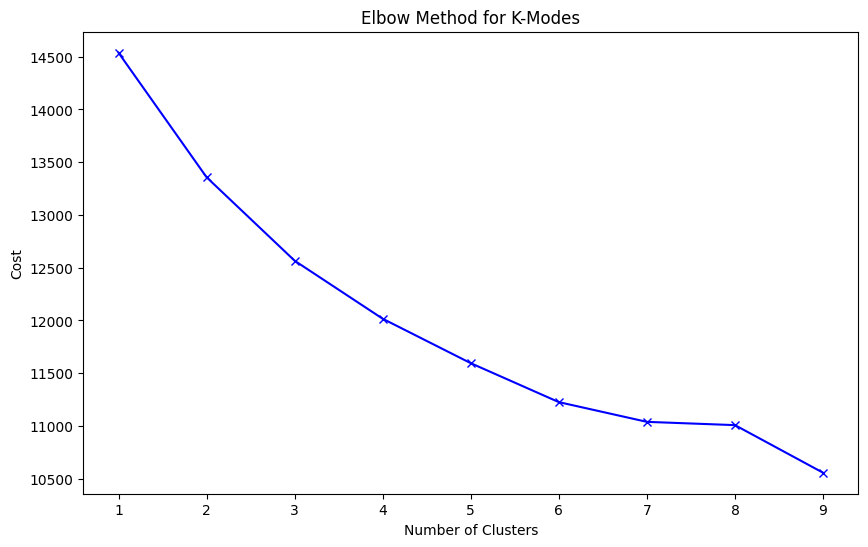

In [ ]:
# Encode the categorical data
label_encoders = {}
for column in df_km.columns:
    le = LabelEncoder()
    df_km[column] = le.fit_transform(df_km[column])
    label_encoders[column] = le

# Calculate the cost for different numbers of clusters and plot the elbow curve
costs = []
K = range(1, 10)  # Range of cluster numbers to be tested

for num_clusters in K:
    km = KModes(n_clusters=num_clusters, init='Huang', n_init=5, verbose=1)
    clusters = km.fit_predict(df_km)
    costs.append(km.cost_)

# Plot the elbow curve
plt.figure(figsize=(10, 6))
plt.plot(K, costs, 'bx-')
plt.xlabel('Number of Clusters')
plt.ylabel('Cost')
plt.title('Elbow Method for K-Modes')
plt.show()

The elbow curve is used to help choose the most appropriate number of clusters in models such as K-Modes. It shows how the model cost decreases as the number of clusters increases. Normally, the cost drops sharply at first and then starts to decrease more slowly. The point where this change in slope happens, the “elbow,” suggests a good balance between model simplicity and clustering quality. In practice, it helps identify the number of clusters that best represents the data without adding unnecessary complexity.

In [ ]:
# random categorical data - TEST
data = np.random.choice(20, (100, 10))

km = KModes(n_clusters=4, init='Huang', n_init=5, verbose=1)

clusters = km.fit_predict(data)

Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 17, cost: 796.0
Run 1, iteration: 2/100, moves: 5, cost: 796.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 2, iteration: 1/100, moves: 23, cost: 792.0
Run 2, iteration: 2/100, moves: 6, cost: 792.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 3, iteration: 1/100, moves: 19, cost: 803.0
Run 3, iteration: 2/100, moves: 6, cost: 798.0
Run 3, iteration: 3/100, moves: 4, cost: 794.0
Run 3, iteration: 4/100, moves: 2, cost: 793.0
Run 3, iteration: 5/100, moves: 0, cost: 793.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 4, iteration: 1/100, moves: 23, cost: 793.0
Run 4, iteration: 2/100, moves: 3, cost: 792.0
Run 4, iteration: 3/100, moves: 0, cost: 792.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 5, iteration: 1/100, moves: 

In [ ]:
# Treinar o modelo K-Modes com 5 clusters
km = KModes(n_clusters=5, init='Huang', n_init=5, verbose=1)
clusters = km.fit_predict(df_km)

Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 892, cost: 12008.0
Run 1, iteration: 2/100, moves: 320, cost: 12008.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 2, iteration: 1/100, moves: 858, cost: 11706.0
Run 2, iteration: 2/100, moves: 80, cost: 11706.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 3, iteration: 1/100, moves: 602, cost: 12383.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 4, iteration: 1/100, moves: 958, cost: 12108.0
Run 4, iteration: 2/100, moves: 375, cost: 12014.0
Run 4, iteration: 3/100, moves: 23, cost: 12014.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 5, iteration: 1/100, moves: 717, cost: 11835.0
Best run was number 2


In [ ]:
# Add the cluster labels to the original dataframe
df['Cluster'] = clusters

Cluster
0    25.779133
1    24.457995
2    23.475610
3    17.852304
4     8.434959
Name: count, dtype: float64


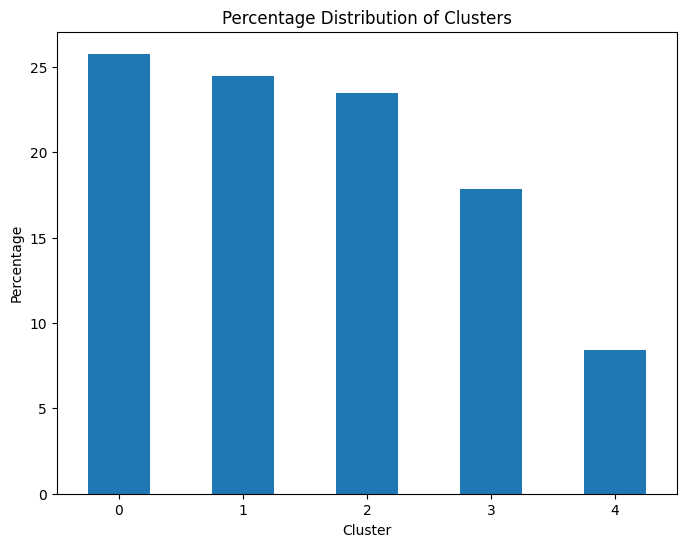

In [ ]:
# Calculate the cluster percentages and prepare the data for the chart
cluster_counts = df['Cluster'].value_counts()
cluster_percentages = (cluster_counts / cluster_counts.sum()) * 100

# Display the percentage distribution
print(cluster_percentages)

# Plot the percentage distribution
plt.figure(figsize=(8, 6))
cluster_percentages.plot(kind='bar')
plt.title('Percentage Distribution of Clusters')
plt.xlabel('Cluster')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.show()

In [ ]:
# Group the data by cluster and calculate descriptive statistics
cluster_characteristics = df.groupby('Cluster').agg({
    'Grade':  lambda x: x.value_counts().idxmax(),
    'NineBlockScore':  lambda x: x.value_counts().idxmax(),
    'AttritionRisk': lambda x: x.value_counts().idxmax(),
    'NeedsVisibility': lambda x: x.value_counts().idxmax(),
    'ReadyForBroaderScope': lambda x: x.value_counts().idxmax(),
    'MismatchedRole': lambda x: x.value_counts().idxmax(),
    'PromotionInLastYear': lambda x: x.value_counts().idxmax(),
    'PromotionPriority': lambda x: x.value_counts().idxmax(),
    'YearsInGradeCategory': lambda x: x.value_counts().idxmax()
}).reset_index()

# Display the resulting dataframe
cluster_characteristics

,Cluster,Grade,NineBlockScore,AttritionRisk,NeedsVisibility,ReadyForBroaderScope,MismatchedRole,PromotionInLastYear,PromotionPriority,YearsInGradeCategory
0,0,Senior 1,Seven,NO,NO,NO,NO,NO,NO,Up to one year
1,1,Manager 1,Five,NO,YES,YES,NO,NO,NO,Up to one year
2,2,Senior Manager 1,Five,NO,NO,NO,NO,NO,NO,Two to five years
3,3,Manager 1,Five,NO,NO,NO,NO,NO,NO,One to two years
4,4,Manager 1,Six,NO,NO,NO,NO,NO,NO,Up to one year
